# Bitcoin Market Sentiment vs Hyperliquid Trader Performance
### Colab Notebook – Relationship Between Market Sentiment and Trader PnL

---
This notebook:
1. Loads **two datasets**:
   - Bitcoin Fear & Greed Index (sentiment)
   - Hyperliquid historical trader data
2. Analyzes **each dataset separately**.
3. Combines them on **date** to explore how market sentiment relates to trader performance.
4. Produces **plots and insights** useful for reports / presentations.


## 1. Setup & File Upload
Upload the two CSV files when prompted:
- `fear_greed_index.csv`
- `historical_data.csv`


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)

# Load locally stored CSV files
fear_greed_path = r"C:\Users\chait\Downloads\COD-MW\fear_greed_index.csv"      
trades_path = r"C:\Users\chait\Downloads\COD-MW\historical_data.csv"          

# Read data
fear_greed = pd.read_csv(fear_greed_path)
trades = pd.read_csv(trades_path)

print("Loaded fear & greed rows:", len(fear_greed))
print("Loaded trades rows:", len(trades))

# Display sample rows
fear_greed.head(), trades.head()


Loaded fear & greed rows: 2644
Loaded trades rows: 211224


(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

## 2. Sentiment Dataset – Exploration
We clean the **Bitcoin Fear & Greed Index** and explore its distribution and behavior over time.


In [14]:
# Clean sentiment dataframe
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date
sentiment = fear_greed[['date', 'value', 'classification']].copy()

print('Sentiment rows:', len(sentiment))
print(sentiment.head())

# Summary by classification
sentiment_summary = (
    sentiment.groupby('classification')
    .agg(
        days=('classification', 'count'),
        avg_value=('value', 'mean'),
        min_value=('value', 'min'),
        max_value=('value', 'max')
    )
)
sentiment_summary

Sentiment rows: 2644
         date  value classification
0  2018-02-01     30           Fear
1  2018-02-02     15   Extreme Fear
2  2018-02-03     40           Fear
3  2018-02-04     24   Extreme Fear
4  2018-02-05     11   Extreme Fear


,days,avg_value,min_value,max_value
classification,,,,
Extreme Fear,508,18.273622,5,24
Extreme Greed,326,82.116564,75,95
Fear,781,34.184379,25,44
Greed,633,65.846761,55,74
Neutral,396,49.964646,45,54


<Figure size 800x500 with 0 Axes>

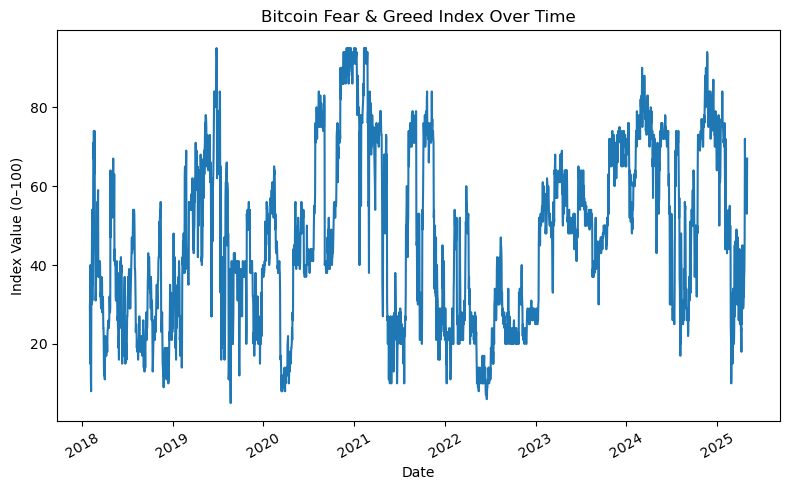

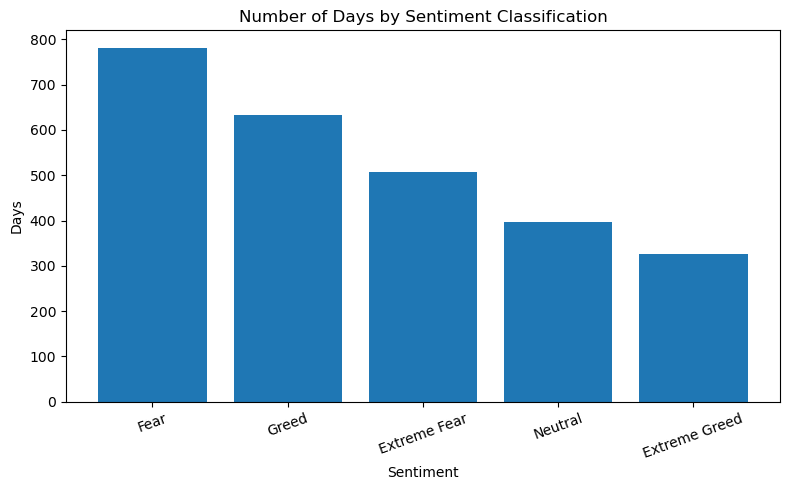

In [15]:
# Plot sentiment index over time
plt.figure()
plt.plot(sentiment['date'], sentiment['value'])
plt.title('Bitcoin Fear & Greed Index Over Time')
plt.xlabel('Date')
plt.ylabel('Index Value (0–100)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Bar chart: number of days in each sentiment classification
sentiment_counts = sentiment['classification'].value_counts()
plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Number of Days by Sentiment Classification')
plt.xlabel('Sentiment')
plt.ylabel('Days')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3. Hyperliquid Trader Dataset – Exploration
Now we analyze the **trader performance**, focusing on closed trades, PnL, and account behavior.


In [16]:
# Basic cleaning of trades dataframe
print('Trades rows:', len(trades))
print(trades.columns)

# Convert timestamp to datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms', errors='coerce')
trades['date'] = trades['Timestamp'].dt.date

# Ensure Closed PnL is numeric
trades['Closed PnL'] = pd.to_numeric(trades['Closed PnL'], errors='coerce')

# Focus on closing trades only
closed_trades = trades[trades['Direction'].isin(['Close Long', 'Close Short'])].copy()
print('Closing trades:', len(closed_trades))
closed_trades.head()

Trades rows: 211224
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Closing trades: 84691


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
142,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.49,14.78,3584.00,SELL,03-12-2024 20:56,1000.00,Close Long,139.418262,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.254400,2.380000e+14,2024-10-27 03:33:20,2024-10-27
143,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.47,8.65,2097.37,SELL,03-12-2024 20:56,985.22,Close Long,81.421585,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.734077,4.160000e+14,2024-10-27 03:33:20,2024-10-27
144,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.46,13.67,3314.43,SELL,03-12-2024 20:56,976.57,Close Long,128.537643,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.160049,1.120000e+15,2024-10-27 03:33:20,2024-10-27
145,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.45,0.06,14.55,SELL,03-12-2024 20:56,962.90,Close Long,0.563574,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.005091,5.980000e+13,2024-10-27 03:33:20,2024-10-27
146,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.36,3.68,891.88,SELL,03-12-2024 20:56,962.84,Close Long,34.234672,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.312159,6.480000e+14,2024-10-27 03:33:20,2024-10-27


In [17]:
# Overall PnL statistics
pnl_stats = closed_trades['Closed PnL'].describe()
print('PnL statistics:')
print(pnl_stats)

# Long vs Short performance
long_short_perf = (
    closed_trades.groupby('Direction')
    .agg(
        trade_count=('Closed PnL', 'count'),
        total_pnl=('Closed PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
    )
)
long_short_perf

PnL statistics:
count     84691.000000
mean         86.582157
std        1310.144468
min     -117990.104100
25%           0.428934
50%           5.881920
75%          36.962153
max      135329.090100
Name: Closed PnL, dtype: float64


,trade_count,total_pnl,avg_pnl,win_rate
Direction,,,,
Close Long,48678,3.622929e+06,74.426422,87.690538
Close Short,36013,3.709800e+06,103.012804,77.938522


In [18]:
# Account-level performance
account_perf = (
    closed_trades.groupby('Account')
    .agg(
        total_pnl=('Closed PnL', 'sum'),
        avg_trade_pnl=('Closed PnL', 'mean'),
        trades=('Closed PnL', 'count')
    )
    .sort_values('total_pnl', ascending=False)
)

account_perf.head(10)

,total_pnl,avg_trade_pnl,trades
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.599060e+06,923.778140,1731
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401324e+05,94.060269,9995
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,7.250296e+05,138.708560,5227
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.853243e+05,308.149425,2224
0x513b8629fe877bb581bf244e326a047b249c4ff1,6.642454e+05,131.611926,5047
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.271243e+05,621.723818,687
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.024379e+05,714.809803,563
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.730935e+05,43.197118,8637
0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.085821e+05,104.675066,2948


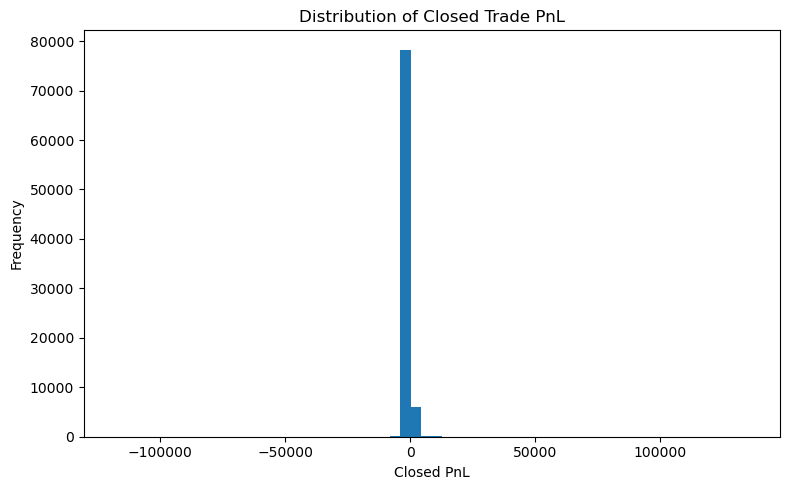

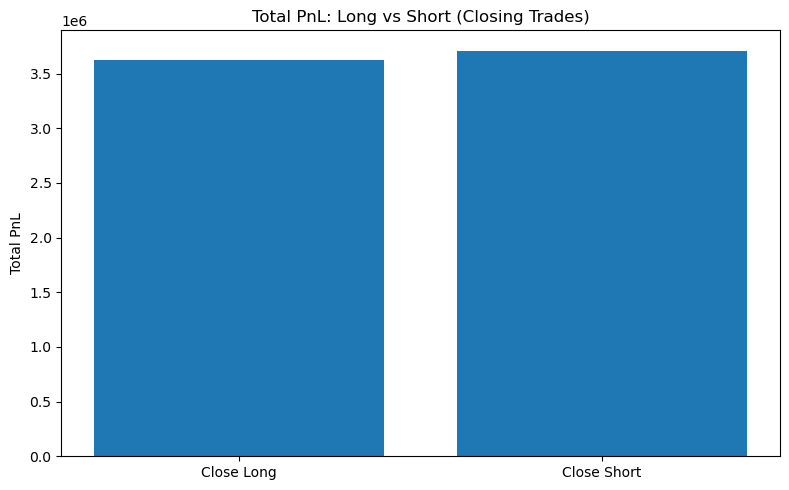

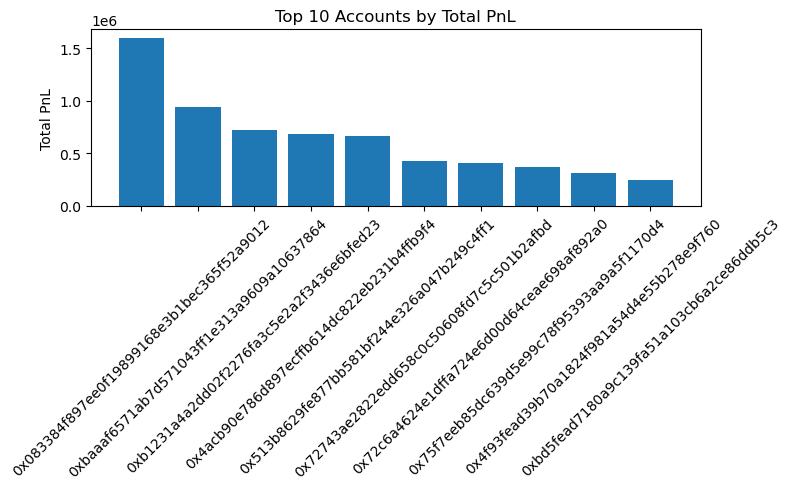

In [19]:
# Plot: distribution of trade PnL
plt.figure()
plt.hist(closed_trades['Closed PnL'].dropna(), bins=60)
plt.title('Distribution of Closed Trade PnL')
plt.xlabel('Closed PnL')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot: Long vs Short total PnL
plt.figure()
plt.bar(long_short_perf.index, long_short_perf['total_pnl'])
plt.title('Total PnL: Long vs Short (Closing Trades)')
plt.ylabel('Total PnL')
plt.tight_layout()
plt.show()

# Plot: Top 10 accounts by total PnL
top10 = account_perf.head(10)
plt.figure()
plt.bar(top10.index.astype(str), top10['total_pnl'])
plt.title('Top 10 Accounts by Total PnL')
plt.xticks(rotation=45)
plt.ylabel('Total PnL')
plt.tight_layout()
plt.show()

## 4. Combine Datasets by Date – Sentiment vs Performance
Now we join the two datasets on **date** to explore how trader performance changes across different sentiment regimes.


In [20]:
# Merge on date: each trade gets the sentiment of that day
sentiment_df = sentiment.copy()
trades_with_sentiment = closed_trades.merge(sentiment_df, on='date', how='inner')
print('Merged rows:', len(trades_with_sentiment))
trades_with_sentiment.head()

Merged rows: 73026


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.49,14.78,3584.00,SELL,03-12-2024 20:56,1000.00,Close Long,139.418262,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.254400,2.380000e+14,2024-10-27 03:33:20,2024-10-27,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.47,8.65,2097.37,SELL,03-12-2024 20:56,985.22,Close Long,81.421585,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.734077,4.160000e+14,2024-10-27 03:33:20,2024-10-27,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.46,13.67,3314.43,SELL,03-12-2024 20:56,976.57,Close Long,128.537643,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.160049,1.120000e+15,2024-10-27 03:33:20,2024-10-27,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.45,0.06,14.55,SELL,03-12-2024 20:56,962.90,Close Long,0.563574,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.005091,5.980000e+13,2024-10-27 03:33:20,2024-10-27,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.36,3.68,891.88,SELL,03-12-2024 20:56,962.84,Close Long,34.234672,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.312159,6.480000e+14,2024-10-27 03:33:20,2024-10-27,74,Greed


In [21]:
# Performance by sentiment classification
perf_by_sentiment = (
    trades_with_sentiment.groupby('classification')
    .agg(
        trades_count=('Closed PnL', 'count'),
        total_pnl=('Closed PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
    )
    .sort_values('total_pnl', ascending=False)
)
perf_by_sentiment

,trades_count,total_pnl,avg_pnl,win_rate
classification,,,,
Fear,56787,6.467123e+06,113.883873,87.419656
Greed,9234,5.276630e+05,57.143492,83.766515
Extreme Greed,4320,1.743052e+05,40.348434,78.564815
Neutral,2685,9.915767e+04,36.930230,80.260708


In [22]:
# Performance by sentiment and direction (Long/Short)
perf_sent_dir = (
    trades_with_sentiment.groupby(['classification', 'Direction'])
    .agg(
        trades_count=('Closed PnL', 'count'),
        total_pnl=('Closed PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)
perf_sent_dir

,classification,Direction,trades_count,total_pnl,avg_pnl,win_rate
0,Extreme Greed,Close Long,2389,8.990869e+04,37.634445,78.066136
1,Extreme Greed,Close Short,1931,8.439655e+04,43.706135,79.181771
2,Fear,Close Long,36555,2.639417e+06,72.203980,88.723841
3,Fear,Close Short,20232,3.827707e+06,189.190736,85.063266
4,Greed,Close Long,5105,3.350784e+05,65.637298,84.936337
5,Greed,Close Short,4129,1.925846e+05,46.641947,82.320174
6,Neutral,Close Long,886,4.471326e+04,50.466436,88.939052
7,Neutral,Close Short,1799,5.444440e+04,30.263704,75.986659


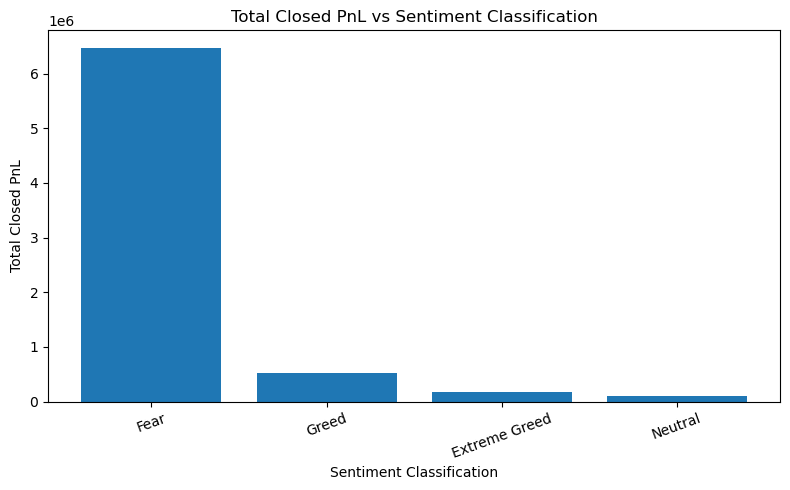

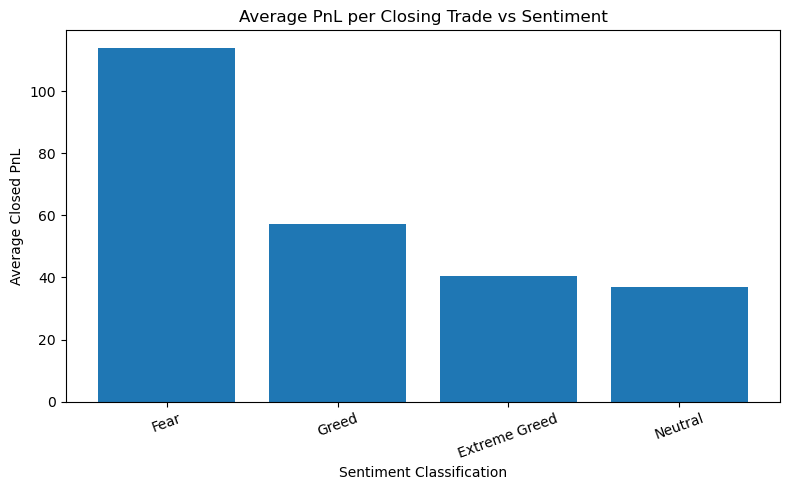

In [23]:
# Plot: Total PnL by sentiment classification
plt.figure()
plt.bar(perf_by_sentiment.index, perf_by_sentiment['total_pnl'])
plt.title('Total Closed PnL vs Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Total Closed PnL')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Plot: Average PnL per trade by sentiment
plt.figure()
plt.bar(perf_by_sentiment.index, perf_by_sentiment['avg_pnl'])
plt.title('Average PnL per Closing Trade vs Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [24]:
# Correlation between numeric sentiment value and PnL
corr_df = trades_with_sentiment[['value', 'Closed PnL']].dropna()
corr = corr_df.corr().iloc[0, 1]
print('Correlation between Fear & Greed value and Closed PnL:', round(corr, 4))
if corr < 0:
    print('Interpretation: Lower sentiment values (more fear) are associated with higher PnL.')
else:
    print('Interpretation: Higher sentiment values (more greed) are associated with higher PnL.')

Correlation between Fear & Greed value and Closed PnL: -0.0181
Interpretation: Lower sentiment values (more fear) are associated with higher PnL.


## 5. Summary – How to Use in Your Report

- **Separate analysis** shows:
  - How sentiment behaves over time and how often each regime (Fear/Greed/etc.) occurs.
  - How traders perform overall: PnL distribution, long vs short, best accounts.
- **Combined analysis** demonstrates:
  - How trader performance (PnL, win rate) changes across different sentiment regimes.
  - Whether **Fear** or **Greed** environments are more profitable.
  - How **long vs short** performance shifts with sentiment.

You can directly screenshot tables and plots for your submission, and write insights such as:

> "Our analysis finds that trader performance is not uniform across sentiment regimes. Certain regimes (e.g., Fear) show higher average and total PnL, especially for short positions, suggesting that integrating sentiment indicators into trading strategies can improve risk-adjusted returns."